<a href="https://colab.research.google.com/github/Kavia-M/Data_science_course-Intellipaat/blob/main/Python/Assignments/Assignment_Quiz/Kmeans_Assignment_Quiz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

his dataset has been obtained from UCI ML Repository.
https://archive.ics.uci.edu/ml/datasets/Facebook+Live+Sellers+in+Thailand

The ‘Facebook Live Sellers in Thailand’ is a dataset present in UCI Machine Learning Datasets. The
data includes 7050 observations and twelve attributes. The data is about the live selling attribute on
the Facebook platform. Each record consists of details about the time live details of the sale are
published to Facebook and engagements in the data. The engagements are regular Facebook
dealings such as sharing and emoji rection.

| Column Name     | Description                                               |
|-----------------|----------------------------------------------------------|
| Status ID       | Id of the status                                         |
| Status Type     | Media type of the post (video, photo, link, status)      |
| Status Published| Date and time of the status being posted                 |
| Num_reactions   | Number of reactions given to that post                   |
| Num_comments    | Number of comments on the post                           |
| num_shares      | Number of shares made for that post                      |
| num_likes       | Number of Thumbs up emojis gave to the post              |
| num_loves       | Number of heart emojis given to the post                 |
| num_wows        | Number of wow emojis given to the post                   |
| num_hahas       | Number of haha emojis given to the post                  |
| num_sads        | Number of sad emojis given to the post                   |
| num_angrys      | Number of angry emojis given to the post                 |


Business Problem:

Live Shopping on Facebook is an interactive way to sell items, connect straight with viewers, and
gain likely customers, all in real-time. When you sell products through Live Shopping on Facebook,
you are live streaming as you feature and demonstrate your products. Small vendors can now reach
a more expansive audience and connect with many clients. You need to implement K-Means
clustering to find intrinsic batches within the dataset that depict the same status_type behavior. The
status_type behavior variable consists of posts of a distinct nature (video, photos, statuses, and
links).

In [1]:
pip install ucimlrepo

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The below cell is taken from the uci repo

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
facebook_live_sellers_in_thailand = fetch_ucirepo(id=488)

# data (as pandas dataframes)
X = facebook_live_sellers_in_thailand.data.features
y = facebook_live_sellers_in_thailand.data.targets

# metadata
print(facebook_live_sellers_in_thailand.metadata)

# variable information
print(facebook_live_sellers_in_thailand.variables)


{'uci_id': 488, 'name': 'Facebook Live Sellers in Thailand', 'repository_url': 'https://archive.ics.uci.edu/dataset/488/facebook+live+sellers+in+thailand', 'data_url': 'https://archive.ics.uci.edu/static/public/488/data.csv', 'abstract': 'Facebook pages of 10 Thai fashion and cosmetics retail sellers. Posts of a different nature (video, photos, statuses, and links). Engagement metrics consist of comments, shares, and reactions.', 'area': 'Business', 'tasks': ['Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 7051, 'num_features': 11, 'feature_types': ['Integer'], 'demographics': [], 'target_col': None, 'index_col': ['status_id'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2018, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C5R60S', 'creators': ['Nassim Dehouche'], 'intro_paper': {'ID': 454, 'type': 'NATIVE', 'title': 'Dataset on usage and engagement patterns for Facebook Live sellers in Thailand', 'authors': '

In [4]:
X

,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0
1,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0
2,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0
3,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0
4,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
7045,photo,9/24/2016 2:58,89,0,0,89,0,0,0,0,0
7046,photo,9/23/2016 11:19,16,0,0,14,1,0,1,0,0
7047,photo,9/21/2016 23:03,2,0,0,1,1,0,0,0,0
7048,photo,9/20/2016 0:43,351,12,22,349,2,0,0,0,0


In [5]:
y

In [6]:
facebook_live_sellers_in_thailand

{'data': {'ids':       status_id
  0             1
  1             2
  2             3
  3             4
  4             5
  ...         ...
  7045       7046
  7046       7047
  7047       7048
  7048       7049
  7049       7050
  
  [7050 rows x 1 columns],
  'features':      status_type status_published  num_reactions  num_comments  num_shares  \
  0          video   4/22/2018 6:00            529           512         262   
  1          photo  4/21/2018 22:45            150             0           0   
  2          video   4/21/2018 6:17            227           236          57   
  3          photo   4/21/2018 2:29            111             0           0   
  4          photo   4/18/2018 3:22            213             0           0   
  ...          ...              ...            ...           ...         ...   
  7045       photo   9/24/2016 2:58             89             0           0   
  7046       photo  9/23/2016 11:19             16             0           0   
  7047 

In [7]:
facebook_live_sellers_in_thailand.keys()

dict_keys(['data', 'metadata', 'variables'])

In [8]:
facebook_live_sellers_in_thailand['data']

{'ids':       status_id
 0             1
 1             2
 2             3
 3             4
 4             5
 ...         ...
 7045       7046
 7046       7047
 7047       7048
 7048       7049
 7049       7050
 
 [7050 rows x 1 columns],
 'features':      status_type status_published  num_reactions  num_comments  num_shares  \
 0          video   4/22/2018 6:00            529           512         262   
 1          photo  4/21/2018 22:45            150             0           0   
 2          video   4/21/2018 6:17            227           236          57   
 3          photo   4/21/2018 2:29            111             0           0   
 4          photo   4/18/2018 3:22            213             0           0   
 ...          ...              ...            ...           ...         ...   
 7045       photo   9/24/2016 2:58             89             0           0   
 7046       photo  9/23/2016 11:19             16             0           0   
 7047       photo  9/21/2016 23:03    

In [9]:
type(facebook_live_sellers_in_thailand['data'])

ucimlrepo.dotdict.dotdict

In [10]:
facebook_live_sellers_in_thailand['data'].keys()

dict_keys(['ids', 'features', 'targets', 'original', 'headers'])

In [11]:
facebook_live_sellers_in_thailand['data']['ids']

,status_id
0,1
1,2
2,3
3,4
4,5
...,...
7045,7046
7046,7047
7047,7048
7048,7049


In [12]:
type(facebook_live_sellers_in_thailand['data']['ids'])

pandas.core.frame.DataFrame

In [13]:
facebook_live_sellers_in_thailand['data']['features']

,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0
1,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0
2,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0
3,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0
4,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
7045,photo,9/24/2016 2:58,89,0,0,89,0,0,0,0,0
7046,photo,9/23/2016 11:19,16,0,0,14,1,0,1,0,0
7047,photo,9/21/2016 23:03,2,0,0,1,1,0,0,0,0
7048,photo,9/20/2016 0:43,351,12,22,349,2,0,0,0,0


In [14]:
facebook_live_sellers_in_thailand['data']['original']

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0
3,4,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0
4,5,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
7045,7046,photo,9/24/2016 2:58,89,0,0,89,0,0,0,0,0
7046,7047,photo,9/23/2016 11:19,16,0,0,14,1,0,1,0,0
7047,7048,photo,9/21/2016 23:03,2,0,0,1,1,0,0,0,0
7048,7049,photo,9/20/2016 0:43,351,12,22,349,2,0,0,0,0


In [15]:
facebook_live_sellers_in_thailand['data'].targets

In [16]:
print(facebook_live_sellers_in_thailand['data']['targets'])

None


In [17]:
facebook_live_sellers_in_thailand['data']['headers']

Index(['status_id', 'status_type', 'status_published', 'num_reactions',
       'num_comments', 'num_shares', 'num_likes', 'num_loves', 'num_wows',
       'num_hahas', 'num_sads', 'num_angrys'],
      dtype='object')

In [18]:
len(facebook_live_sellers_in_thailand['data']['headers'])

12

In [19]:
type(facebook_live_sellers_in_thailand['data']['headers'])

pandas.core.indexes.base.Index

# Below I am using what is downloaded from Intellipaat quiz attachment

In [20]:
df = pd.read_csv('/content/Live.csv')

In [21]:
df

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,246675545449582_1649696485147474,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,246675545449582_1649426988507757,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,246675545449582_1648730588577397,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,246675545449582_1648576705259452,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,246675545449582_1645700502213739,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7045,1050855161656896_1061863470556065,photo,9/24/2016 2:58,89,0,0,89,0,0,0,0,0,NaN,NaN,NaN,NaN
7046,1050855161656896_1061334757275603,photo,9/23/2016 11:19,16,0,0,14,1,0,1,0,0,NaN,NaN,NaN,NaN
7047,1050855161656896_1060126464063099,photo,9/21/2016 23:03,2,0,0,1,1,0,0,0,0,NaN,NaN,NaN,NaN
7048,1050855161656896_1058663487542730,photo,9/20/2016 0:43,351,12,22,349,2,0,0,0,0,NaN,NaN,NaN,NaN


Column1, Column2, Column3, Column4 are extra junk columns not in uci repo dataset direct python import, but downloaded from uci also has those

uci mentions 7051 instances but 7050 only there, may be they counted the header row also

In [22]:
df['Column1'].value_counts()

,count
Column1,


In [23]:
df['Column2'].value_counts()

,count
Column2,


In [24]:
df['Column3'].value_counts()

,count
Column3,


In [25]:
df['Column4'].value_counts()

,count
Column4,


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   object 
 1   status_type       7050 non-null   object 
 2   status_published  7050 non-null   object 
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(9), object(3)
memory 

In [27]:
df.shape

(7050, 16)

In [28]:
X.shape

(7050, 11)

In [29]:
facebook_live_sellers_in_thailand['data']['original'].shape

(7050, 12)

1) How many columns contain null data?
- 5
- 4
- 0
- 3

In [30]:
df.isnull().sum()

,0
status_id,0
status_type,0
status_published,0
num_reactions,0
num_comments,0
num_shares,0
num_likes,0
num_loves,0
num_wows,0
num_hahas,0


1. Answer - 4

In [31]:
df.drop(['Column1', 'Column2', 'Column3', 'Column4'], axis=1, inplace=True)

In [32]:
df

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,246675545449582_1649696485147474,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0
1,246675545449582_1649426988507757,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0
2,246675545449582_1648730588577397,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0
3,246675545449582_1648576705259452,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0
4,246675545449582_1645700502213739,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
7045,1050855161656896_1061863470556065,photo,9/24/2016 2:58,89,0,0,89,0,0,0,0,0
7046,1050855161656896_1061334757275603,photo,9/23/2016 11:19,16,0,0,14,1,0,1,0,0
7047,1050855161656896_1060126464063099,photo,9/21/2016 23:03,2,0,0,1,1,0,0,0,0
7048,1050855161656896_1058663487542730,photo,9/20/2016 0:43,351,12,22,349,2,0,0,0,0


In [33]:
df.isnull().sum()

,0
status_id,0
status_type,0
status_published,0
num_reactions,0
num_comments,0
num_shares,0
num_likes,0
num_loves,0
num_wows,0
num_hahas,0


In [34]:
df.isnull().sum().sum()

np.int64(0)

In [35]:
df.duplicated().sum()

np.int64(51)

In [36]:
X.duplicated().sum()

np.int64(54)

In [37]:
facebook_live_sellers_in_thailand['data']['original'].duplicated().sum()

np.int64(0)

In [38]:
df

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,246675545449582_1649696485147474,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0
1,246675545449582_1649426988507757,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0
2,246675545449582_1648730588577397,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0
3,246675545449582_1648576705259452,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0
4,246675545449582_1645700502213739,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
7045,1050855161656896_1061863470556065,photo,9/24/2016 2:58,89,0,0,89,0,0,0,0,0
7046,1050855161656896_1061334757275603,photo,9/23/2016 11:19,16,0,0,14,1,0,1,0,0
7047,1050855161656896_1060126464063099,photo,9/21/2016 23:03,2,0,0,1,1,0,0,0,0
7048,1050855161656896_1058663487542730,photo,9/20/2016 0:43,351,12,22,349,2,0,0,0,0


In [39]:
facebook_live_sellers_in_thailand['data']['original']

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0
3,4,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0
4,5,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
7045,7046,photo,9/24/2016 2:58,89,0,0,89,0,0,0,0,0
7046,7047,photo,9/23/2016 11:19,16,0,0,14,1,0,1,0,0
7047,7048,photo,9/21/2016 23:03,2,0,0,1,1,0,0,0,0
7048,7049,photo,9/20/2016 0:43,351,12,22,349,2,0,0,0,0


2) How many status ids are unique?
- 6997
- 3984
- 4509
- 6503

In [40]:
len(df['status_id'].unique())

6997

2. Answer - 6997

3) How many video post has been made for live selling:
- 1827
- 2871
- 2345
- 2334

In [41]:
df['status_type'].unique()

array(['video', 'photo', 'link', 'status'], dtype=object)

In [42]:
df['status_type'].value_counts()

,count
status_type,
photo,4288
video,2334
status,365
link,63


In [43]:
df['status_type'].value_counts()['video']

np.int64(2334)

In [44]:
df[df['status_type'] == 'video'].count()

,0
status_id,2334
status_type,2334
status_published,2334
num_reactions,2334
num_comments,2334
num_shares,2334
num_likes,2334
num_loves,2334
num_wows,2334
num_hahas,2334


3. Answer - 2334

4) How many likes have been given to the photo posted on 4/19/2018 at 22:26?
- 359
- 493
- 379
- 293

that column is of type string only

In [45]:
type(df['status_published'][0])

str

In [46]:
df[df['status_published']=='4/19/2018 22:26']

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
4592,725980084255106_850951205091326,photo,4/19/2018 22:26,383,5,6,379,2,2,0,0,0


In [47]:
df[df['status_published']=='4/19/2018 22:26'].num_likes

,num_likes
4592,379


In [48]:
df[df['status_published']=='4/19/2018 22:26']['num_likes']

,num_likes
4592,379


4. Answer - 379

5) How many total shares were made for the video post that was posted on 7/15/2017 at 10:52?
- 173
- 167
- 139
- 153

In [49]:
df[df['status_published']=='7/15/2017 10:52']['num_shares']

,num_shares
6977,167


5. Answer - 167

6) What does k means do?
- None of the above
- Finds relationships between dependent and independent data
- Finds probability of elements
- Group similar elements

6. Answer - Group similar elements

7) What output will the below code give?

```python
colour=['red','blue','green','yellow','cyan']
n=0

for i in range(0,len(colour)):
  plt.scatter(X[df['Clusters(5)']==i],Y[df['Clusters(5)']==i],s=10,c=colour[i])

plt.scatter(k.cluster_centers_[:,0] ,k.cluster_centers_[:,1], color='black')
```

- Gives 2 clusters
- Gives 5 clusters
- Gives 3 clusters
- Gives 5 clusters with midpoints

In [50]:
colour=['red','blue','green','yellow','cyan']
n=0
for i in range(0,len(colour)):
  plt.scatter(X[df['Clusters(5)']==i],Y[df['Clusters(5)']==i],s=10,c=colour[i])
  plt.scatter(k.cluster_centers_[:,0] ,k.cluster_centers_[:,1], color='black')

KeyError: 'Clusters(5)'

## From chat gpt


Let’s carefully analyze the code step by step:

```python
colour = ['red','blue','green','yellow','cyan']  
n = 0  
for i in range(0, len(colour)):  
    plt.scatter(X[df['Clusters(5)']==i], Y[df['Clusters(5)']==i], s=10, c=colour[i])  

plt.scatter(k.cluster_centers_[:,0], k.cluster_centers_[:,1], color='black')  
```

### 🔎 Breakdown

1. **`colour` list has 5 colors** → matches **5 clusters**.
2. **Loop `for i in range(0, len(colour))`** → runs from 0 to 4 (5 iterations).
3. Inside loop:

   * `df['Clusters(5)'] == i` means → plotting data points belonging to cluster *i*.
   * So each iteration colors one cluster.
4. After plotting clusters → `plt.scatter(k.cluster_centers_[:,0], k.cluster_centers_[:,1], color='black')` plots the **cluster centroids** (midpoints).

### ✅ Answer

The code will **plot 5 clusters with their midpoints shown in black**.

Correct option:
**👉 “Gives 5 clusters with midpoints”**

---


### inside loop line explanation


```python
plt.scatter(X[df['Clusters(5)']==i], Y[df['Clusters(5)']==i], s=10, c=colour[i])
```

---

### 🔎 Step-by-step explanation

1. **`df['Clusters(5)']`**

   * This column in your DataFrame `df` contains the **cluster labels** assigned by KMeans.
   * Example: If you ran `KMeans(n_clusters=5)`, this column might look like:

     ```
     0
     2
     1
     0
     4
     ...
     ```

     meaning each data point belongs to cluster 0, 1, 2, 3, or 4.

---

2. **`df['Clusters(5)'] == i`**

   * This creates a **boolean mask**:

     * If `i = 0`, it returns `True` for rows where the cluster label is 0, and `False` otherwise.
     * Example: `[True, False, False, True, False, ...]`

---

3. **`X[df['Clusters(5)'] == i]` and `Y[df['Clusters(5)'] == i]`**

   * `X` and `Y` are your feature arrays (say, x-axis and y-axis values).
   * Using the mask, you select **only the data points that belong to cluster `i`**.
   * So for `i=0`, this gives all the `X` and `Y` values of points in cluster 0.

---

4. **`plt.scatter(... , ..., s=10, c=colour[i])`**

   * `plt.scatter(x, y, ...)` plots points on a scatter plot.
   * Here, it plots only the **points of cluster `i`**.
   * `s=10` → sets the size of each point to 10 (small dots).
   * `c=colour[i]` → picks a color from the `colour` list for cluster `i`.

     * i=0 → red
     * i=1 → blue
     * i=2 → green
     * i=3 → yellow
     * i=4 → cyan

---

#### ✅ Meaning

👉 This line **plots all the data points belonging to one cluster (cluster i) on the scatter plot, using a specific color from the list.**
The loop repeats this for each cluster, so all clusters get plotted in different colors.

---

### Make blobs

Good catch 👍 Let me explain what **`make_blobs`** means.

---

### 🔎 `make_blobs` in scikit-learn

* It's a **function from `sklearn.datasets`** used to **generate synthetic (fake) data** for clustering and classification experiments.
* It creates **Gaussian blobs** (clouds of points) around specified or random centers.

---

### 📌 Syntax

```python
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=5, cluster_std=1.0, random_state=42)
```

* **`n_samples=300`** → total number of data points. (default n_samples=100)
* **`centers=5`** → number of clusters (true groups to generate).
* **`cluster_std=1.0`** → how spread out each cluster is (bigger = more scattered).
* **`random_state=42`** → for reproducibility (same random data each run).

---

### 📌 What it returns

* `X` → a NumPy array of shape `(n_samples, n_features)` → the actual data points.
  Example (if `n_features=2` which is default):

  ```
  [[-7.726420, -8.394957],
   [-7.076440, -7.772469],
   [-2.978672,  9.556846],
   ... ]
  ```

* `y` → the **true labels** of each point (which blob it belongs to).

  ```
  [3, 3, 1, 2, 2, ...]
  ```

---

### 📊 Why we use it

* In clustering problems like K-Means, we often need **toy datasets** to test and visualize.
* `make_blobs` is **perfect** because:

  * It produces clean, spherical clusters.
  * We can control how many clusters and points to generate.
  * Easy to plot in 2D.

---


In [51]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

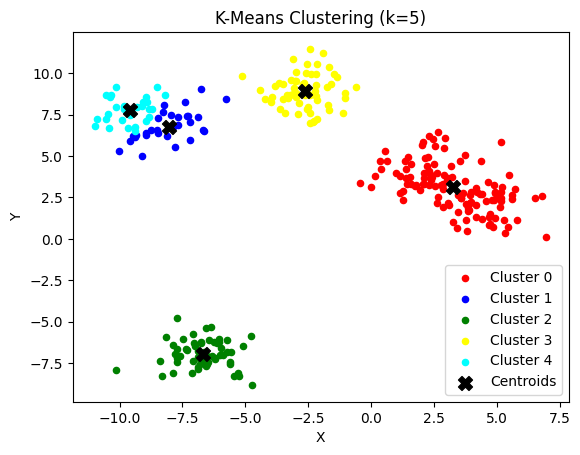

          X         Y  Clusters(5)
0 -0.623012  9.188864            3
1  0.543714  5.305206            0
2 -2.300334  7.054616            3
3  4.416416  2.687170            0
4 -3.837384  9.211147            3
5 -8.950656  7.102553            4
6  1.429906  3.297461            0
7 -6.803823 -7.557271            2
8 -8.454262  7.290828            1
9  2.599372  3.958406            0


In [52]:
# 1. Create synthetic dataset (300 points, 2 features)
X1, y1 = make_blobs(n_samples=300, centers=5, cluster_std=1.0, random_state=42)

# 2. Convert into DataFrame
df1 = pd.DataFrame(X1, columns=['X', 'Y'])

# 3. Apply KMeans (k=5 clusters)
k1 = KMeans(n_clusters=5, random_state=42)
df1['Clusters(5)'] = k1.fit_predict(df1[['X', 'Y']])

# 4. Plotting
colours = ['red','blue','green','yellow','cyan']

for i in range(0, len(colours)):
    plt.scatter(df1['X'][df1['Clusters(5)'] == i],
                df1['Y'][df1['Clusters(5)'] == i],
                s=20, c=colours[i], label=f"Cluster {i}")

# Plot centroids
plt.scatter(k1.cluster_centers_[:,0],  # all rows column 0 as one array
            k1.cluster_centers_[:,1],  # all rows colunm 1 as one array
            color='black', marker='X', s=100, label='Centroids')

plt.title("K-Means Clustering (k=5)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

# 5. Show first 10 rows of df
print(df1.head(10))

/tmp/ipython-input-1448345196.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


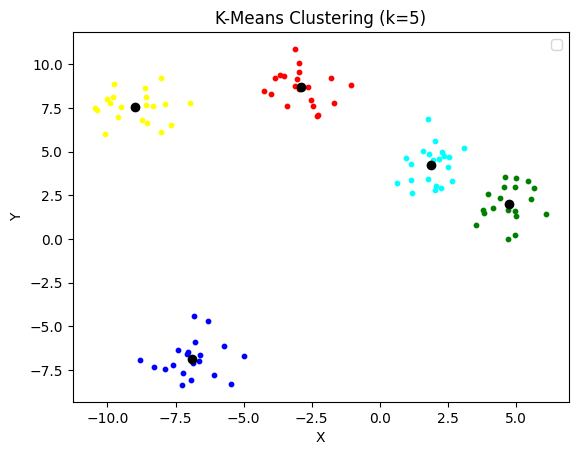

          X         Y  Clusters(5)
0 -6.292770 -4.689654            1
1  2.035302  5.614986            4
2 -2.972615  8.548556            0
3  0.644631  3.223627            4
4 -8.738676  6.820047            3
X2 shape is (100, 2)


In [53]:
# 1. Create synthetic dataset (100 points, 2 features) which are default
X2, y2 = make_blobs(centers=5, random_state=42)

# 2. Convert into DataFrame
df2 = pd.DataFrame(X2, columns=['X', 'Y'])

# 3. Apply KMeans (k=5 clusters)
k2 = KMeans(n_clusters=5, random_state=42)
df2['Clusters(5)'] = k2.fit_predict(df2[['X', 'Y']])

# 4. Plotting
colours = ['red','blue','green','yellow','cyan']

for i in range(0, len(colours)):
    plt.scatter(df2['X'][df2['Clusters(5)'] == i],
                df2['Y'][df2['Clusters(5)'] == i],
                s=10, c=colours[i])

# Plot centroids
plt.scatter(k2.cluster_centers_[:,0],  # all rows column 0 as one array
            k2.cluster_centers_[:,1],  # all rows colunm 1 as one array
            color='black')

plt.title("K-Means Clustering (k=5)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

# 5. Show first 10 rows of df
print(df2.head())
print(f"X2 shape is {X2.shape}")

In [54]:
from sklearn.metrics import accuracy_score

In [55]:
# check accuracy

acc1 = accuracy_score(y1, df1['Clusters(5)'])
print(acc1)

acc2 = accuracy_score(y2, df2['Clusters(5)'])
print(acc2)

0.2
0.6


In [56]:
y1

array([0, 4, 0, 1, 0, 3, 4, 2, 3, 4, 1, 0, 1, 0, 4, 0, 1, 1, 4, 0, 0, 1,
       0, 4, 4, 0, 2, 4, 1, 2, 3, 4, 4, 3, 2, 1, 1, 4, 3, 1, 0, 1, 2, 3,
       4, 3, 0, 2, 4, 2, 3, 4, 2, 3, 0, 3, 1, 0, 3, 2, 0, 3, 4, 4, 2, 1,
       2, 2, 2, 2, 1, 2, 3, 4, 3, 0, 3, 3, 4, 0, 2, 0, 0, 4, 0, 2, 3, 1,
       1, 4, 4, 4, 0, 4, 0, 0, 4, 3, 1, 4, 3, 3, 1, 2, 0, 0, 0, 1, 0, 1,
       3, 4, 1, 1, 0, 0, 0, 2, 3, 3, 3, 2, 3, 3, 0, 2, 4, 4, 3, 0, 1, 3,
       1, 0, 0, 0, 0, 1, 2, 4, 0, 3, 0, 1, 4, 0, 4, 2, 1, 2, 1, 2, 2, 1,
       0, 4, 2, 3, 0, 1, 3, 3, 4, 1, 0, 3, 4, 4, 1, 4, 2, 0, 1, 1, 0, 1,
       3, 1, 2, 2, 3, 3, 1, 2, 2, 4, 0, 3, 2, 1, 4, 2, 0, 2, 2, 3, 3, 2,
       4, 1, 3, 2, 1, 1, 3, 0, 0, 2, 2, 0, 2, 3, 4, 2, 0, 1, 3, 3, 2, 4,
       3, 3, 4, 3, 4, 1, 3, 4, 3, 4, 3, 1, 1, 2, 4, 1, 1, 1, 4, 0, 3, 1,
       2, 4, 2, 3, 4, 4, 2, 2, 1, 4, 3, 2, 3, 4, 2, 4, 2, 4, 2, 0, 4, 1,
       1, 0, 4, 1, 2, 1, 3, 2, 2, 0, 0, 3, 1, 1, 4, 4, 3, 0, 0, 1, 1, 2,
       2, 2, 4, 1, 3, 1, 2, 3, 0, 3, 2, 0, 4, 0])

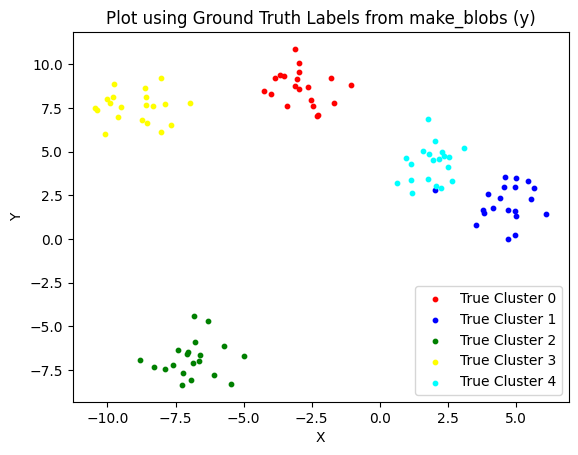

          X         Y  Clusters(5)  True_Cluster
0 -6.292770 -4.689654            1             2
1  2.035302  5.614986            4             4
2 -2.972615  8.548556            0             0
3  0.644631  3.223627            4             4
4 -8.738676  6.820047            3             3
5 -7.222342 -7.682387            1             2
6  5.001515  1.328050            2             1
7  4.160705  1.787511            2             1
8  4.604053  3.537813            2             1
9 -3.109836  8.722592            0             0


In [57]:
df2['True_Cluster'] = y2   # Ground truth labels

# 3. Plot using the TRUE labels (y)
colours = ['red','blue','green','yellow','cyan']

for i in range(0, len(colours)):
    plt.scatter(df2['X'][df2['True_Cluster'] == i],
                df2['Y'][df2['True_Cluster'] == i],
                s=10, c=colours[i], label=f"True Cluster {i}")

plt.title("Plot using Ground Truth Labels from make_blobs (y)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

# Print first 10 rows
print(df2.head(10))

In [58]:
k2.cluster_centers_

array([[-2.87559086,  8.66758942],
       [-6.88732163, -6.84846391],
       [ 4.73987759,  2.0192694 ],
       [-8.97484095,  7.55134937],
       [ 1.90144007,  4.22597687]])

Let’s break down **what `k.cluster_centers_` means** in KMeans.

---

### 🔎 KMeans Basics

* KMeans tries to split data into **K groups (clusters)**.
* Each cluster is represented by a **centroid** → the “center” of all points in that cluster.
* A centroid is simply the **mean of all X and Y coordinates** of points assigned to that cluster.

👉 That’s why it’s called **K-Means** (clusters are based on the mean).

---

### 🔎 Attribute: `k.cluster_centers_`

After you fit a `KMeans` model:

```python
k = KMeans(n_clusters=5, random_state=42)
k.fit(df[['X','Y']])
```

* **`k.cluster_centers_`** gives you a NumPy array with the coordinates of each centroid.
* Shape: `(n_clusters, n_features)`

Example (if 5 clusters in 2D data):

```python
print(k.cluster_centers_)
```

might give:

```
[[-2.87559086,  -2.87758942]
 [-6.88732163, -6.84846391]
 [ 4.73987759,  2.0192694 ]
 [-8.97484095,  7.55134937]
 [ 1.90144007,  4.22597687]]
```

This means:

* Cluster 0 centroid ≈ (-2.87, -2.87)
* Cluster 1 centroid ≈ (-6.88, -6.84)
* etc.

---

### 🔎 Why do we plot them?

```python
plt.scatter(k.cluster_centers_[:,0],
            k.cluster_centers_[:,1],
            color='black', marker='X', s=100, label='Centroids')
```

* `k.cluster_centers_[:,0]` → X coordinates of all centroids.
* `k.cluster_centers_[:,1]` → Y coordinates of all centroids.
* `marker='X'` → draws them as a big **X**.
* `s=100` → makes them larger than data points.
* `color='black'` → makes them stand out.

So you see **black X markers in the middle of each cluster**.

---

### ✅ Intuition

The centroid is the **point where the cluster “balances”** — the average of all points inside it.
KMeans updates these centroids **iteratively** until they stop moving (convergence).

---


7. Answer - Gives 5 clusters with midpoints

8) Which method is used to decide the optimal number of clusters in k-means clustering?
- Append method
- Elbow method
- None
- Evaluation Method

8. Answer - Elbow method

9) In what cases is K Means used?
- Classification
- None of the above
- Clustering
- Regression

9. Answer - Clustering

10) For exploration, do we use Hierarchical Clustering?
- FALSE
- TRUE

Hierarchical Clustering is of 2 types:
 1. agglomerative clustering
 2. divisive clustering

**what “exploration” means** in this context.

---

### 🔎 What is *exploration* in clustering / data science?

* **Exploration** usually refers to **Exploratory Data Analysis (EDA)** → the stage where we try to **understand the structure and patterns of data** before building a final model.
* In clustering, *exploration* means:

  * Checking if the data naturally forms groups.
  * Understanding **how many clusters** might exist.
  * Visualizing relationships (scatter plots, dendrograms, heatmaps).
  * Trying different methods (like KMeans, Hierarchical, DBSCAN) to see which gives meaningful clusters.

---

### 🔎 Why Hierarchical Clustering is linked with exploration

* Unlike KMeans (where you must fix **K** upfront), **Hierarchical Clustering** builds a **tree (dendrogram)**.
* From this tree, you can **explore different levels of grouping** (maybe 2 clusters, maybe 5, maybe 10).
* This makes it very handy in the **exploratory phase**, because it gives insights into the **natural structure** of the data without fixing `K` immediately.

---

👉 So in short:
**Exploration** = the process of analyzing your dataset to discover hidden patterns and structures (like natural groupings), often before fixing parameters or finalizing the model.

---


Hierarchical clustering comes with dendograms which is a part of exploratory data analysis EDA

10. Answer - TRUE

11) Which is the function used for the K Means?
- Clusters
- heatmap
- KMeans
- None of the above



```python
from sklearn.cluster import KMeans
k2 = KMeans(n_clusters=5, random_state=42)
```



KMeans is function in sklearn used for K means

[scikit learn KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

```
class sklearn.cluster.KMeans(n_clusters=8, *, init='k-means++', n_init='auto', max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='lloyd')
```

11. Answer - KMeans

12) How to train the K-means model?
- train_test_split()
- fit()
- train()
- predict()

always for a model, fit is used to fit the training data that is TRAINING

predict is used to predict for testing data or any new data. in KMeans we get the closest cluster for that new data point

```python
df2['Clusters(5)'] = k2.fit_predict(df2[['X', 'Y']])
```

fit_predict -> fits and returns the cluster id for each data point so that we stored it in df2

12. Answer - fit()

13) What does random_state do?
- Shows states
- Checks and validate data when code is run multiple times.
- All of the above.
- Used to split data

Random state is used in train test split but it is used in model building also, so it does not exclusively splits the data

The random_state parameter in machine learning, particularly in libraries like scikit-learn, is used to set the seed for the random number generator. This ensures that the results of operations involving randomness, such as data splitting or model initialization, are reproducible.

Here's why it's important and what it specifically does:

• **Reproducibility**: When you set a specific integer value for `random_state`, you guarantee that the same random sequence will be generated every time you run your code. This means that if you split your data using `train_test_split` with `random_state=42`, you will always get the exact same training and testing sets, and consequently, the same model performance if all other factors remain constant.
• **Consistency** in Model Evaluation: When comparing different models or tuning hyperparameters, a consistent data split is crucial for reliable evaluation. Using `random_state` ensures that your comparisons are based on the same data partitions.
• Debugging and **Sharing Code**: A fixed `random_state` makes debugging easier as you can consistently reproduce issues. It also allows others to replicate your results exactly, which is vital for sharing research or tutorials.

Therefore, the correct answer is that `random_state` ***checks and validates data when code is run multiple times*** by ensuring reproducibility of random processes, especially when splitting data.
Although it does not validate anything explicitly.


It **does not "show states"** in the sense of displaying internal states, **nor is it exclusively "used to split data"** although that is a primary use case. It applies to any operation involving pseudo-random number generation.


Due to ambuiguity in Answer, we shall choose all the above

13. Answer - All of the above.


13. Answer - **All the above is WRONG ANSWER** correct answer is not shown in results

14) How to check which data is placed under which Cluster?
- None of the above
- Intertia_
- Cluster_
- Labels_

*   List item
*   List item



In [59]:
k2.inertia_

159.83755106823406

**KMeans attributes** in scikit-learn:

---

### 1️⃣ `inertia_`

* **Definition:**
  Inertia is the **sum of squared distances of samples to their nearest cluster center**.

* Think of it as a **measure of how tight your clusters are**. Lower inertia → points are closer to centroids → better clustering.

* Formula (for K clusters):

  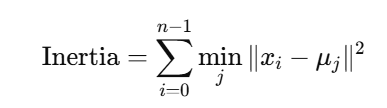

  Where (x_i) = data point, (\mu_j) = centroid of cluster j.

* **Use case:**

  * Often used in the **Elbow Method** to decide the optimal K.
  * Plot `inertia_` vs `K` and look for the “elbow” point.

---

### 2️⃣ `cluster_centers_`

* **Definition:**
  The **coordinates of the centroids** of each cluster.
* Shape: `(n_clusters, n_features)`
* Example:

  ```python
  k2 = KMeans(n_clusters=3)
  k2.fit_predict(df2[['X','Y']])
  print(k2.cluster_centers_)
  ```

  Might output:

  ```
  [[1.2, 3.5],
   [5.7, 8.1],
   [2.9, 0.5]]
  ```
* **Use case:**

  * To plot cluster centers.
  * To assign new points to nearest cluster.

---

### 3️⃣ `labels_`

* **Definition:**
  The **cluster label assigned to each data point** after fitting KMeans.

* Example:

  ```python
  print(k2.labels_)
  ```

  Output:

  ```
  [0, 0, 1, 2, 1, 0, ...]
  ```

  * Each element corresponds to a row in your dataset.
  * `0` → assigned to cluster 0, `1` → cluster 1, etc.

* **Use case:**

  * To group or color points according to cluster.
  * Often added as a column to a DataFrame:

    ```python
    df2['Cluster'] = k2.labels_
    ```

---

### 🔑 Summary Table

| Attribute          | What it gives                         | Use case                                 |
| ------------------ | ------------------------------------- | ---------------------------------------- |
| `inertia_`         | Sum of squared distances to centroids | Measure cluster tightness / Elbow method |
| `cluster_centers_` | Centroid coordinates of each cluster  | Plotting, assigning new points           |
| `labels_`          | Cluster index for each point          | Label points, add to DataFrame           |

---


From scikit learn:

### Attributes:

**cluster_centers_** : *ndarray of shape (n_clusters, n_features)*  
Coordinates of cluster centers. If the algorithm stops before fully converging (see `tol` and `max_iter`), these will not be consistent with `labels_`.

**labels_** : *ndarray of shape (n_samples,)*  
Labels of each point.

**inertia_** : *float*  
Sum of squared distances of samples to their closest cluster center, weighted by the sample weights if provided.

**n_iter_** : *int*  
Number of iterations run.

**n_features_in_** : *int*  
Number of features seen during `fit`.  
> Added in version 0.24.

**feature_names_in_** : *ndarray of shape (n_features_in_,)*  
Names of features seen during `fit`. Defined only when `X` has feature names that are all strings.  
> Added in version 1.0.


In [60]:
k2.labels_

array([1, 4, 0, 4, 3, 1, 2, 2, 2, 0, 0, 1, 4, 0, 2, 3, 4, 4, 1, 3, 3, 2,
       0, 1, 3, 3, 4, 4, 4, 2, 1, 3, 4, 4, 4, 3, 0, 0, 0, 2, 1, 2, 2, 2,
       3, 0, 0, 1, 3, 4, 4, 2, 2, 1, 2, 3, 4, 4, 0, 0, 2, 0, 3, 1, 3, 1,
       4, 4, 1, 4, 3, 1, 1, 1, 4, 3, 2, 3, 4, 1, 4, 1, 3, 2, 3, 0, 3, 0,
       0, 0, 3, 0, 1, 2, 1, 0, 1, 0, 2, 2], dtype=int32)

which lables_ we can see each point is placed under which cluster

14. Answer - Labels_

15) Why do we perform standard scalar?
- Removing standard values
- Adding standard values
- None of the above
- Standardizing the data

In [61]:
from sklearn.preprocessing import StandardScaler

Let’s carefully explain this one.

---

### 🔎 Why we perform **StandardScaler**

* **StandardScaler** is a preprocessing technique in scikit-learn.
* It **transforms features so that they have mean = 0 and standard deviation = 1**.
* Formula for each feature (x):
  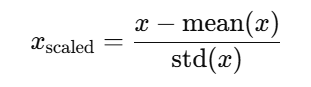

---

### ✅ Purpose

* Ensures that **all features contribute equally** to distance-based algorithms like KMeans, PCA, or KNN.
* Prevents features with larger numeric ranges from dominating the clustering or model.

---

### ❌ Options analysis

* **Removing standard values** → ❌ Wrong
* **Adding standard values** → ❌ Wrong
* **None of the above** → ❌ Wrong
* **Standardizing the data** → ✅ Correct

---

💡 **Intuition:**
If one feature is in the range 0–1 and another in 0–1000, KMeans (or any distance-based algorithm) will be biased toward the larger feature. StandardScaler fixes this.

---




```python
from sklearn.preprocessing import StandardScaler
```

this is function in sklearn for standardization of data

15. Answer - Standardizing the data

16)
Perform the following operations on the dataset:

● Drop Status id and status published column.

● Use a label encoder to encode the status type column.

● Standardize the data using min-max scalar

● Create a K means model for 2 clusters.


 From the above model, what is the inter-cluster variance of the model?

- 284 to 290
- 345 to 350
- 210 to 220
- 235 to 240

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   status_id         7050 non-null   object
 1   status_type       7050 non-null   object
 2   status_published  7050 non-null   object
 3   num_reactions     7050 non-null   int64 
 4   num_comments      7050 non-null   int64 
 5   num_shares        7050 non-null   int64 
 6   num_likes         7050 non-null   int64 
 7   num_loves         7050 non-null   int64 
 8   num_wows          7050 non-null   int64 
 9   num_hahas         7050 non-null   int64 
 10  num_sads          7050 non-null   int64 
 11  num_angrys        7050 non-null   int64 
dtypes: int64(9), object(3)
memory usage: 661.1+ KB


#### Step 1 - Drop Status id and status published column.

In [63]:
df.drop(['status_id', 'status_published'], axis=1, inplace=True)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   status_type    7050 non-null   object
 1   num_reactions  7050 non-null   int64 
 2   num_comments   7050 non-null   int64 
 3   num_shares     7050 non-null   int64 
 4   num_likes      7050 non-null   int64 
 5   num_loves      7050 non-null   int64 
 6   num_wows       7050 non-null   int64 
 7   num_hahas      7050 non-null   int64 
 8   num_sads       7050 non-null   int64 
 9   num_angrys     7050 non-null   int64 
dtypes: int64(9), object(1)
memory usage: 550.9+ KB


#### Step 2 - Use a label encoder to encode the status type column.

In [65]:
from sklearn.preprocessing import LabelEncoder

In [66]:
le = LabelEncoder()

In [67]:
df['status_type'].value_counts()

,count
status_type,
photo,4288
video,2334
status,365
link,63


In [68]:
df['status_type'] = le.fit_transform(df['status_type'])

In [69]:
df['status_type'].value_counts()

,count
status_type,
1,4288
3,2334
2,365
0,63


In [70]:
le.classes_

array(['link', 'photo', 'status', 'video'], dtype=object)

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   status_type    7050 non-null   int64
 1   num_reactions  7050 non-null   int64
 2   num_comments   7050 non-null   int64
 3   num_shares     7050 non-null   int64
 4   num_likes      7050 non-null   int64
 5   num_loves      7050 non-null   int64
 6   num_wows       7050 non-null   int64
 7   num_hahas      7050 non-null   int64
 8   num_sads       7050 non-null   int64
 9   num_angrys     7050 non-null   int64
dtypes: int64(10)
memory usage: 550.9 KB


#### Step 3 - Standardize the data using min-max scalar

In [72]:
from sklearn.preprocessing import minmax_scale

In [73]:
from sklearn.preprocessing import MinMaxScaler

[scikit learn MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)

[scikit learn minmax_scale](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.minmax_scale.html)

In [74]:
minmax_scale

<function sklearn.preprocessing._data.minmax_scale(X, feature_range=(0, 1), *, axis=0, copy=True)>

---

##### 🔎 **Min-Max Scaling (Normalization)**

**Definition:**

* Min-Max Scaling transforms each feature to a **fixed range**, usually **0 to 1**.
* Formula for each value (x):

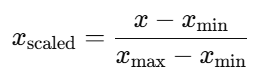

Where:

* (x) = original value
* (x_{\min}) = minimum value of the feature
* (x_{\max}) = maximum value of the feature
* (x_{\text{scaled}}) = scaled value between 0 and 1

---

##### 🔎 Key Points

* All features are **rescaled to the same range**, so they are **comparable**.
* Unlike **StandardScaler**, which gives mean = 0 and std = 1, **MinMaxScaler** keeps the **original distribution shape** but compresses it to [0,1] or another specified range.
* Very useful for algorithms sensitive to **feature magnitude**, like KMeans, Neural Networks, or Distance-based methods.

---

##### 🔑 Example

Original data: `[10, 20, 30, 40, 50]`

* min = 10, max = 50

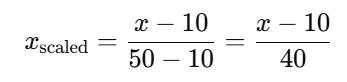

* Scaled values → `[0, 0.25, 0.5, 0.75, 1]`

---

##### 🔎 Difference from StandardScaler

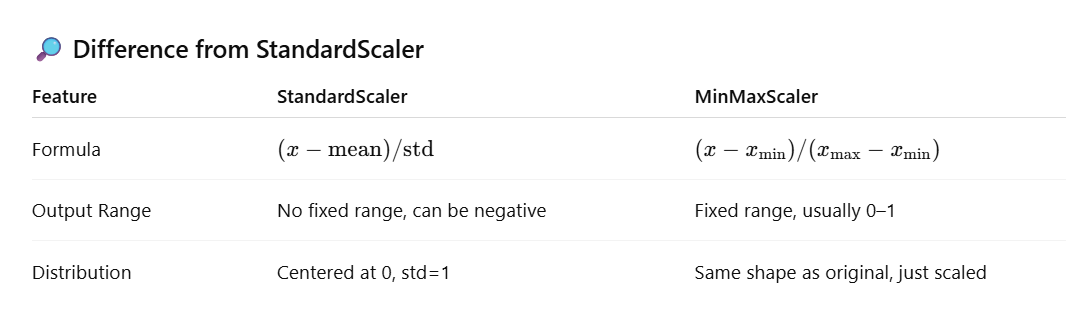

---

💡 **Intuition:**

* **StandardScaler** → makes features comparable by variance (distance from mean).
* **MinMaxScaler** → makes features comparable by scaling them to the same range.

---


[![Compare the effect of different scalers on data with outliers — scikit-learn 1.7.2 documentation](https://images.openai.com/thumbnails/url/hxeFHnicu1mUUVJSUGylr5-al1xUWVCSmqJbkpRnoJdeXJJYkpmsl5yfq5-Zm5ieWmxfaAuUsXL0S7F0Tw72dHdJc3H28w9ICQoscks2MDdwLXXzLijwzC4KLbb0K6xICfGK9yx2DEhy8cpJ8zTycvXzM07KiM9TKwYAr4Iosg)](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html?utm_source=chatgpt.com)

Absolutely, let's delve into the distinction between `sklearn.preprocessing.minmax_scale` and `sklearn.preprocessing.MinMaxScaler` in scikit-learn.

---

##### 🧪 `minmax_scale` Function

* **Type**: Function
* **Usage**: Ideal for quick, one-off transformations of data arrays.
* **Returns**: A NumPy array with the scaled data.
* **Example**:

```python
  from sklearn.preprocessing import minmax_scale
  X_scaled = minmax_scale(X, feature_range=(0, 1))
```

This function is straightforward and doesn't require fitting or transformation steps. It's suitable for scenarios where you need to scale data immediately without the need for reusability.

---

##### 🧰 `MinMaxScaler` Class

* **Type**: Transformer class
* **Usage**: Best for scenarios where you need to fit the scaler to training data and then apply the same transformation to test data or new data points.
* **Returns**: An instance of `MinMaxScaler` with methods `.fit()`, `.transform()`, and `.fit_transform()`.
* **Example**:

```python
  from sklearn.preprocessing import MinMaxScaler
  scaler = MinMaxScaler(feature_range=(0, 1))
  X_scaled = scaler.fit_transform(X)
```

Using `MinMaxScaler` is advantageous when you need to ensure that the scaling parameters (min and max values) are consistent across different datasets, which is crucial in machine learning pipelines.

---

##### 🔍 Key Differences

| Feature         | `minmax_scale` Function       | `MinMaxScaler` Class                          |
| --------------- | ----------------------------- | --------------------------------------------- |
| **Type**        | Function                      | Class (Transformer)                           |
| **Fitting**     | Not required                  | Required (`fit()` method)                     |
| **Reusability** | Single-use                    | Reusable across datasets                      |
| **Integration** | Simple, quick transformations | Suitable for pipelines and consistent scaling |
| **Output**      | NumPy array                   | NumPy array                                   |

---

##### ⚠️ Important Consideration

Both methods scale features independently, which means that outliers can significantly influence the scaling process. If your dataset contains outliers, it's advisable to consider alternative scaling methods, such as `RobustScaler`, which is less sensitive to outliers.

In [75]:
mmscaler = MinMaxScaler() # copy false means it transforms inplace but not works for df

In [80]:
df.describe()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
count,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000
mean,1.704965,230.117163,224.356028,40.022553,215.043121,12.728652,1.289362,0.696454,0.243688,0.113191
std,0.942399,462.625309,889.636820,131.599965,449.472357,39.972930,8.719650,3.957183,1.597156,0.726812
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,17.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,59.500000,4.000000,0.000000,58.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.000000,219.000000,23.000000,4.000000,184.750000,3.000000,0.000000,0.000000,0.000000,0.000000
max,3.000000,4710.000000,20990.000000,3424.000000,4710.000000,657.000000,278.000000,157.000000,51.000000,31.000000


In [81]:
df.columns

Index(['status_type', 'num_reactions', 'num_comments', 'num_shares',
       'num_likes', 'num_loves', 'num_wows', 'num_hahas', 'num_sads',
       'num_angrys'],
      dtype='object')

In [82]:
df[df.columns] = mmscaler.fit_transform(df)

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   status_type    7050 non-null   float64
 1   num_reactions  7050 non-null   float64
 2   num_comments   7050 non-null   float64
 3   num_shares     7050 non-null   float64
 4   num_likes      7050 non-null   float64
 5   num_loves      7050 non-null   float64
 6   num_wows       7050 non-null   float64
 7   num_hahas      7050 non-null   float64
 8   num_sads       7050 non-null   float64
 9   num_angrys     7050 non-null   float64
dtypes: float64(10)
memory usage: 550.9 KB


In [84]:
df.describe()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
count,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000
mean,0.568322,0.048857,0.010689,0.011689,0.045657,0.019374,0.004638,0.004436,0.004778,0.003651
std,0.314133,0.098222,0.042384,0.038435,0.095429,0.060842,0.031366,0.025205,0.031317,0.023446
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.333333,0.003609,0.000000,0.000000,0.003609,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.333333,0.012633,0.000191,0.000000,0.012314,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.046497,0.001096,0.001168,0.039225,0.004566,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Step 4 - Create a K means model for 2 clusters.

In [85]:
kmodel= KMeans(n_clusters = 2)

In [86]:
kmodel.fit(df)

KMeans(n_clusters=2)

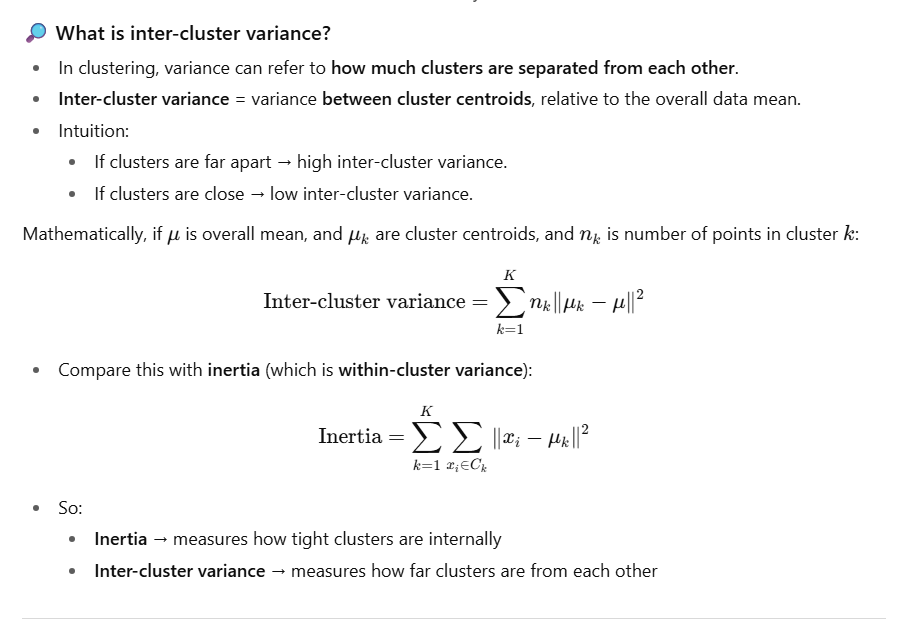

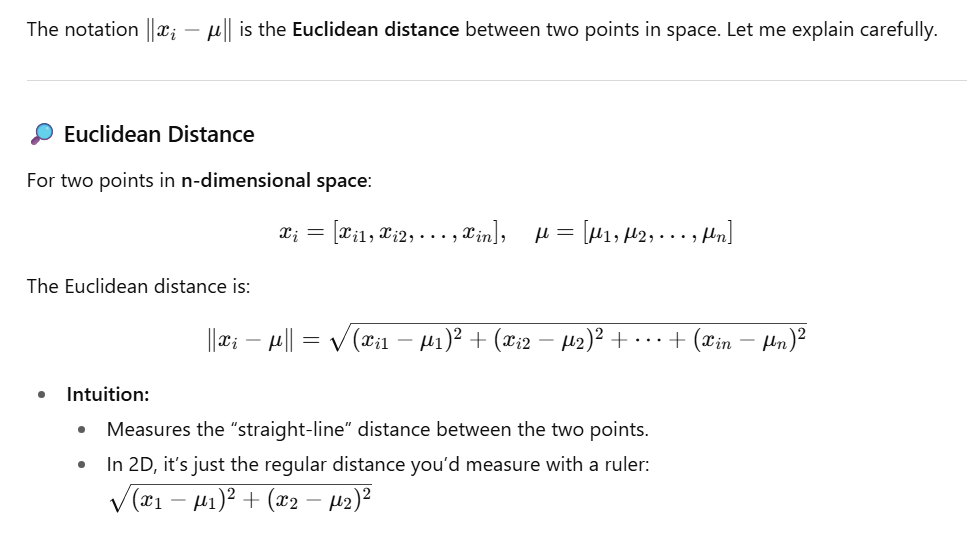

---

##### 🔎 Expression:

```python
(k.cluster_centers_[i] - overall_mean)
```

* This **by itself is not the Euclidean distance**.
* It’s a **vector difference** between the cluster centroid and the overall mean.
* Example in 2D:

```python
cluster_centroid = np.array([5, 3])
overall_mean = np.array([2, 1])
diff = cluster_centroid - overall_mean  # [5-2, 3-1] = [3, 2]
```

* `diff` = vector pointing from overall mean to centroid.

---

##### 🔎 Euclidean distance

* To get the **distance**, you need to compute the **norm of this vector**:

```python
distance = np.linalg.norm(cluster_centroid - overall_mean)
```

* Using the vector `[3, 2]` example:

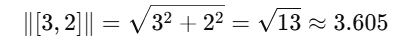

* If you want **squared Euclidean distance** (used in variance formulas), you can do:

```python
squared_distance = np.sum((cluster_centroid - overall_mean)**2)
# 3^2 + 2^2 = 13
```

---

### 🔑 Summary

| Expression                                             | Meaning                              |
| ------------------------------------------------------ | ------------------------------------ |
| `k.cluster_centers_[i] - overall_mean`                 | Vector from overall mean to centroid |
| `np.linalg.norm(k.cluster_centers_[i] - overall_mean)` | Euclidean distance                   |
| `np.sum((k.cluster_centers_[i] - overall_mean)**2)`    | Squared Euclidean distance           |

---


In [87]:
overall_mean = np.mean(df, axis=0)
overall_mean

,0
status_type,0.568322
num_reactions,0.048857
num_comments,0.010689
num_shares,0.011689
num_likes,0.045657
num_loves,0.019374
num_wows,0.004638
num_hahas,0.004436
num_sads,0.004778
num_angrys,0.003651


In [88]:
inter_cluster_variance = sum(
    len(df[kmodel.labels_ == i]) * np.sum((kmodel.cluster_centers_[i] - overall_mean)**2)
    for i in range(kmodel.n_clusters)
)
print(inter_cluster_variance)


659.2216327988579


In [89]:
kmodel.inertia_

240.06686397262683

Inter cluster variance is 659

Intra cluster variance (inertia) is 240

so, as per [stackexchange answer about inter vs intra cluster](https://stats.stackexchange.com/questions/120509/inter-cluster-variance) they say both are almost identical, so we shall go with intra cluster variance which is 240

16. Answer - 235 to 240

## **Marks** - 15/16

only mistake is the random_state - all the above answer is wrong. Correct answer is not shown